# Indicators Strategy Hyperparameter Optimization

Purpose: Perform a high-frequency parameter optimization for the Indicator-Based strategy.

Data Source: Parquet format for optimized loading.

Logic: Uses the generate_actions API with the "Predictability Guardrails" (Min Profit, ADX, and ATR floors) to find a stable baseline for future ML modeling.

In [1]:
%matplotlib inline 

# 1) Wipe out your namespace
%reset -f

# 2) Clear Jupyter’s stored outputs and inputs 
try:
    Out.clear() 
    In.clear()
except NameError:
    pass

# 3) Force Python GC
import gc
gc.collect()

# 4) Free any GPU buffers
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Core Library Imports
import importlib
from libs import params, feats, strats, opts, models_core
importlib.reload(params)
importlib.reload(feats)
importlib.reload(strats)
importlib.reload(opts)
importlib.reload(models_core)

# Standard Data Science Stack
import numpy as np
import pandas as pd
import math
import time
import datetime as dt
from datetime import datetime, time as dt_time
from pathlib import Path

# UI and Progress
from tqdm import tqdm
from IPython.display import clear_output, display

# Plotting Configuration
import matplotlib.pyplot as plt
import seaborn as sns
plt.ioff() # Turn off interactive plotting

# Optimization Stack
import optuna
from optuna.samplers import TPESampler

# Ensure Dataset compatibility for pickling/loading
torch.serialization.add_safe_globals([models_core.DayWindowDataset])

pd.set_option('display.max_columns', None)


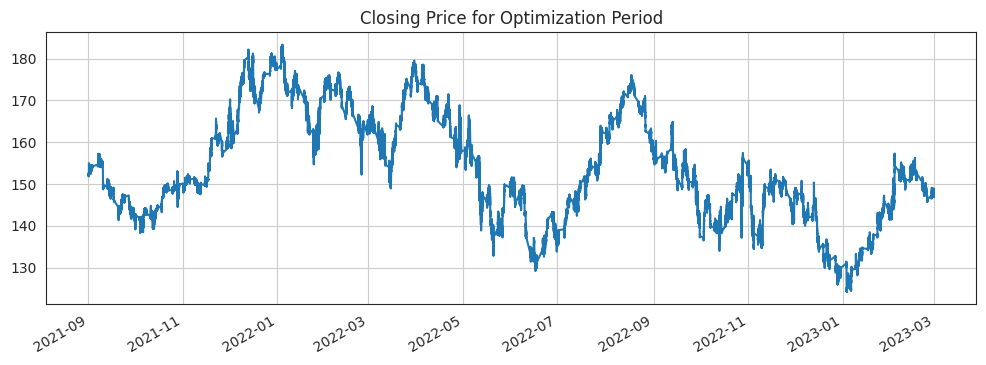

,open,high,low,close,volume,trade_count,vwap,ask,bid,ret,log_ret,body,upper_shad,lower_shad,range_pct,sma_5,sma_pct_5,sma_9,sma_pct_9,sma_21,sma_pct_21,sma_50,sma_pct_50,sma_100,sma_pct_100,ema_2,ema_3,ema_5,ema_7,ema_9,ema_13,ema_21,ema_50,rsi_2,rsi_3,rsi_5,rsi_7,rsi_10,rsi_14,rsi_21,roc_2,roc_3,roc_5,roc_10,roc_21,cci_7,cci_14,cci_20,macd_line_3_10_4,macd_signal_3_10_4,macd_diff_3_10_4,macd_line_6_13_5,macd_signal_6_13_5,macd_diff_6_13_5,macd_line_12_26_9,macd_signal_12_26_9,macd_diff_12_26_9,stoch_k_5_3_3,stoch_d_5_3_3,stoch_k_14_3_3,stoch_d_14_3_3,atr_2,atr_pct_2,plus_di_2,minus_di_2,adx_2,atr_3,atr_pct_3,plus_di_3,minus_di_3,adx_3,atr_5,atr_pct_5,plus_di_5,minus_di_5,adx_5,atr_7,atr_pct_7,plus_di_7,minus_di_7,adx_7,atr_9,atr_pct_9,plus_di_9,minus_di_9,adx_9,atr_14,atr_pct_14,plus_di_14,minus_di_14,adx_14,atr_21,atr_pct_21,plus_di_21,minus_di_21,adx_21,bb_lband_20_2p0,bb_hband_20_2p0,bb_w_20_2p0,bb_lband_20_3p0,bb_hband_20_3p0,bb_w_20_3p0,bb_lband_50_2p0,bb_hband_50_2p0,bb_w_50_2p0,kc_mid_20_20_1.5,kc_l_20_20_1.5,kc_h_20_20_1.5,kc_w_20_20_1.5,kc_mid_20_20_2.0,kc_l_20_20_2.0,kc_h_20_20_2.0,kc_w_20_20_2.0,obv,obv_roll_3,obv_roll_7,obv_roll_21,mfi_7,mfi_14,mfi_20,cmf_7,cmf_14,cmf_20,vol_spike_3,vol_spike_7,vol_spike_14,vol_spike_28,donch_h_10,donch_l_10,donch_w_10,donch_h_20,donch_l_20,donch_w_20,donch_h_55,donch_l_55,donch_w_55,roll_vwap_10,roll_vwap_20,roll_vwap_50,slope_close_5,slope_close_20,slope_close_50,ret_std_5,ret_std_21,ret_std_63,vwap_ohlc_close_session,vwap_dist_session,psar,psar_dist,dist_high_100,dist_low_100
2021-09-01 07:00:00,152.340,152.400,152.200,152.310,2052.0,79.0,152.343289,152.53850,152.08150,0.002633,0.002630,-0.03,0.06,0.11,0.001313,151.956,0.002330,151.911111,0.002626,151.874286,0.002869,151.8499,0.003030,151.862702,0.002945,152.170769,152.096413,152.018578,151.978119,151.953148,151.923549,151.894996,151.867887,99.830969,99.319583,97.879285,96.377536,94.364255,92.108647,88.907688,0.002963,0.003029,0.002963,0.003095,0.003161,233.333333,466.666667,657.602451,0.152531,0.066909,0.085621,0.072060,0.027698,0.044362,0.043925,0.012360,0.031565,0.948276,0.760536,0.948276,0.871648,0.273162,0.001793,94.531328,0.475888,81.122544,0.192093,0.001261,91.590506,0.958774,60.517309,0.123829,0.000813,87.558888,2.103867,36.808390,0.093550,0.000614,84.467536,3.401602,28.421520,0.076254,0.000501,81.984651,4.650623,24.497922,0.053679,0.000352,77.491111,7.239535,19.072892,0.039270,0.000258,73.251549,9.807319,15.994430,151.674268,152.077732,0.002657,151.573401,152.178599,0.003985,151.714905,151.984895,0.001778,151.897444,151.836322,151.958567,0.000805,151.897444,151.815948,151.978941,0.001073,1.529217e+10,1.529216e+10,1.529216e+10,1.529215e+10,89.683822,85.708219,81.744827,0.421322,0.262026,0.233686,0.481389,0.613270,1.023843,1.224605,152.40,151.82,0.003808,152.400000,151.82,0.003808,152.400,151.80,0.003939,151.908041,151.889248,151.866828,0.0980,0.007699,0.001677,0.001151,0.000579,0.000339,152.310000,0.000000,151.820000,0.003217,0.000591,0.003348
2021-09-01 07:01:00,152.310,152.310,152.310,152.310,1163.0,12.0,152.310000,152.53850,152.08150,0.000000,0.000000,0.00,0.00,0.00,0.000000,152.048,0.001723,151.961111,0.002296,151.896667,0.002721,151.8593,0.002968,151.866702,0.002919,152.263590,152.203206,152.115719,152.061089,152.024518,151.978756,151.932724,151.885225,99.830969,99.319583,97.879285,96.377536,94.364255,92.108647,88.907688,0.002633,0.002963,0.003029,0.003095,0.003095,117.878338,235.338654,336.051648,0.192757,0.117249,0.075509,0.106679,0.054025,0.052654,0.071035,0.024095,0.046941,0.896552,0.892720,0.896552,0.911239,0.136581,0.000897,94.531328,0.475888,90.060375,0.128062,0.000841,91.590506,0.958774,72.987565,0.099063,0.000650,87.558888,2.103867,48.508143,0.080186,0.000526,84.467536,3.401602,37.540956,0.067781,0.000445,81.984651,4.650623,31.694142,0.049844,0.000327,77.491111,7.239535,23.632803,0.037400,0.000246,73.251549,9.807319,18.870155,151.624973,152.175027,0.003621,151.487459,152.312541,0.005432,151.672758,152.0458

In [2]:
# Load the data
df_inds = pd.read_parquet(params.indunsc_parquet)

# Ensure it's sorted by index (time)
df_inds.sort_index(inplace=True)

# Apply date slice
df_inds = df_inds[(df_inds.index >= params.start_date_sim) & (df_inds.index < params.end_date_sim)]

# Visual Verification
plt.figure(figsize=(12, 4))
df_inds.close.plot(title="Closing Price for Optimization Period")
plt.grid(True)
plt.show()

df_inds

In [3]:
# {'win_choice': (1, 3),
#  'rsi_min_thresh': (51.96613406306892, 54.552325936931084),
#  'rsi_max_thresh': (46.92746510551783, 50.68765489448216),
#  'adx_thresh': (13.145612755772982, 16.189477244227017),
#  'atr_mult': (1.1474376324347433, 1.8785323675652568),
#  'vwap_atr_mult': (-3.4897818840564696, -2.6218681159435304),
#  'buy_factor': (2.5575071007084045, 4.181452899291596),
#  'sell_factor': (2.805531747323554, 4.723848252676446),
#  'trailstop_pct': (-0.060394600379916175, 0.6899346003799162),
#  'sign_thresh_pair': {'categorical': {'psar_dist|0.0': 1.0}}}

In [4]:
def objective(trial: optuna.Trial) -> float:
    
    # --- Dynamic Window Selection ---
    win_choice = trial.suggest_categorical("win_choice", [2, 3, 5]) # [2, 3, 5, 7, 14, 21]
    col_atr  = f"atr_{win_choice}"
    col_adx  = f"adx_{win_choice}"
    col_rsi  = f"rsi_{win_choice}"
    col_vwap = "vwap_ohlc_close_session" # session anchor

    rsi_min_thresh  = trial.suggest_float("rsi_min_thresh", 20.0, 60.0)
    rsi_max_thresh  = trial.suggest_float("rsi_max_thresh", 40.0, 80.0)
    adx_thresh      = trial.suggest_float("adx_thresh", 10.0, 40.0)       # STRICT Min: 10.0 (Scalp floor); Max: 35.0
    atr_mult        = trial.suggest_float("atr_mult", 1.0, 4.0)          # STRICT Min: 1.0; Max: 5.0
    vwap_atr_mult   = trial.suggest_float("vwap_atr_mult", -5.0, 1.0)   # STRICT Min: -5.0 (Deep mean rev)
    buy_factor      = trial.suggest_float("buy_factor", 0.01, 1000.0, log=True)
    sell_factor     = trial.suggest_float("sell_factor", 0.01, 1000.0, log=True)
    trailstop_pct   = trial.suggest_float("trailstop_pct", 0.1, 2.0)      # STRICT Min: 0.1; Max: 2.0

    # --- Signal/Threshold Combinations (Raw Indicators) ---
    sign_thresh_pair = trial.suggest_categorical("sign_thresh_pair", [ 
        # "ema_5|ema_13",             # Classic fast crossover
        # "ema_9|ema_21",             # Trend follow crossover
        # "macd_diff_3_10_4|0.0",     # Micro-MACD 
        "macd_diff_6_13_5|0.0",     # Fast MACD histogram (Very good for 1m)
        "rsi_3|50.0",               # Ultra-fast momentum flip
        # "rsi_7|50.0",               # Fast RSI momentum
        "cci_7|0.0",                # High-speed CCI
        # "cci_14|0.0",               # Commodity Channel Index (Measures deviation)
        # "mfi_7|50.0",               # Fast Money Flow
        # "mfi_14|50.0",              # Volume-weighted momentum
        "slope_close_5|0.0",        # Instantaneous price trajectory 
        # "vol_spike_3|1.5",          # Extreme volume surge breakout
        # "vol_spike_7|1.2",          # Trade only on 20% volume surges 
        "roc_5|0.0",                 # Rate of Change pure momentum flip
        "psar_dist|0.0",            # Parabolic SAR flip (Price vs SAR)
    ])
    
    col_signal, sign_thresh = sign_thresh_pair.split("|")
    try: 
        sign_thresh = float(sign_thresh) # Handles "0.0", "50.0" ...
    except ValueError:
        pass # Handles "ema_13", "ema_21" ...
    
    print('-' * 160)
    print("Params => " + "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))

    # Reset globals before each simulation
    start_ask = float(df_inds["ask"].iloc[0])
    strats.reset_globals(start_ask) 

    groups = list(df_inds.groupby(df_inds.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Trial {trial.number}", leave=True)
    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):
        # generate_actions handles the weights internally using the factors
        df_actions = strats.generate_actions(
            df              = df_day,
            col_atr         = col_atr,          
            col_adx         = col_adx,          
            col_rsi         = col_rsi,         
            col_vwap        = col_vwap,
            col_signal      = col_signal,
            sign_thresh     = sign_thresh,
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            trailstop_pct   = trailstop_pct,
            buy_factor      = buy_factor,
            sell_factor     = sell_factor,
            sess_start      = params.sess_start_reg,
            sess_end        = params.sess_end       
        )

        sim_results = strats.simulate_trading(
            day             = day,
            df              = df_actions
        )
   
        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)

        del df_actions, sim_results

    final_val = acc.finalize()
    del groups
    gc.collect() 
    return final_val


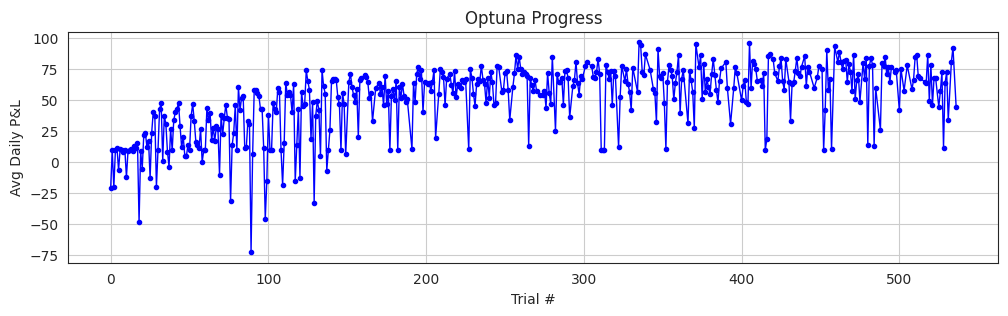

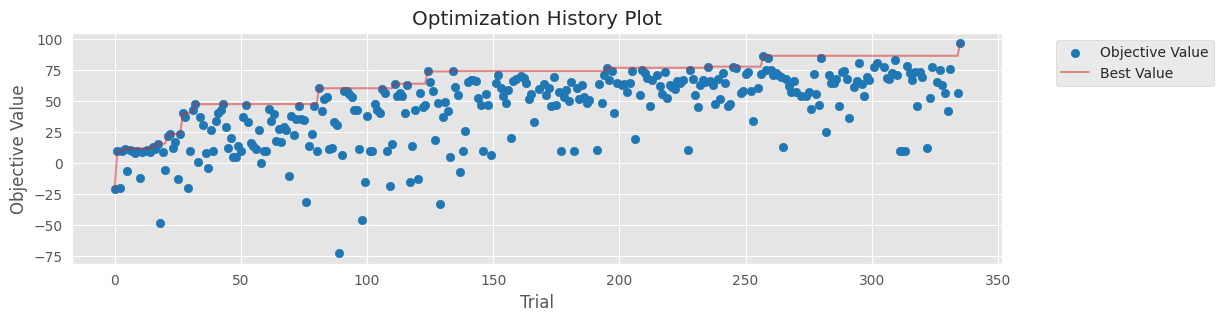

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => win_choice=2; rsi_min_thresh=49.95782390144495; rsi_max_thresh=58.440414326708044; adx_thresh=38.52822196496213; atr_mult=2.842934960151449; vwap_atr_mult=0.7689944406894007; buy_factor=572.6541260771157; sell_factor=262.23508626760315; trailstop_pct=1.1427419430396575; sign_thresh_pair=cci_7|0.0


Trial 0: 100%|██████████| 375/375 [00:14<00:00, 25.61it/s]


[Results] mean_pnl:-30.2893 mean_bh:-9.4138 mean_excess:-20.8755 improv_vs_bh:-221.75%
Action counts: {'Buy': 789, 'Sell': 520, 'Hold': 346451}
Best trial is: 0 with best_val: -20.8755
[save_results] wrote optuna_results/AAPL_-20.8755_pred_IND.csv
[save_best_json] wrote optuna_results/AAPL_-20.8755_pred_IND.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => win_choice=2; rsi_min_thresh=22.44765505836282; rsi_max_thresh=54.44806844932604; adx_thresh=16.950106664995484; atr_mult=3.142826675060731; vwap_atr_mult=-3.8924238222969008; buy_factor=0.03688097269581742; sell_factor=592.2604727781332; trailstop_pct=1.6907526529685022; sign_thresh_pair=roc_5|0.0


Trial 1: 100%|██████████| 375/375 [00:13<00:00, 27.00it/s]


[Results] mean_pnl:0.0000 mean_bh:-9.4138 mean_excess:9.4138 improv_vs_bh:100.00%
Action counts: {'Buy': 218, 'Sell': 0, 'Hold': 347542}
Best trial is: 1 with best_val: 9.4138
[save_results] wrote optuna_results/AAPL_9.4138_pred_IND.csv
[save_best_json] wrote optuna_results/AAPL_9.4138_pred_IND.json


...

Trial 535:  53%|█████▎    | 198/375 [00:07<00:06, 25.86it/s]


[PRUNE] value=50.692220 thr=118.195590
[Results] mean_pnl:-22.1906 mean_bh:-72.8828 mean_excess:50.6922 improv_vs_bh:69.55%
Action counts: {'Buy': 541, 'Sell': 481, 'Hold': 184537}
Best trial is: 335 with best_val: 96.2378
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => win_choice=2; rsi_min_thresh=45.566020733132966; rsi_max_thresh=57.69754245183543; adx_thresh=24.466283116165897; atr_mult=1.151123353756556; vwap_atr_mult=-2.161175560381492; buy_factor=865.8908139262229; sell_factor=1.4502860541501335; trailstop_pct=1.3597503573963128; sign_thresh_pair=macd_diff_6_13_5|0.0


Trial 536: 100%|██████████| 375/375 [00:14<00:00, 25.98it/s]


[Results] mean_pnl:34.9801 mean_bh:-9.4138 mean_excess:44.3940 improv_vs_bh:471.58%
Action counts: {'Buy': 1017, 'Sell': 738, 'Hold': 346005}
Best trial is: 335 with best_val: 96.2378
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => win_choice=2; rsi_min_thresh=43.512776426111955; rsi_max_thresh=56.511502435276164; adx_thresh=22.65729698167812; atr_mult=1.250461232055676; vwap_atr_mult=-2.2695391995934178; buy_factor=624.5333447090527; sell_factor=382.36835041603814; trailstop_pct=0.13091541812608512; sign_thresh_pair=macd_diff_6_13_5|0.0


Trial 537:  29%|██▉       | 108/375 [00:04<00:10, 24.96it/s]

In [ ]:
# Pre-compute per-day slices once
prun_perc         = 80 
report_interval   = 50
n_startup_trials  = 150
n_trials          = 3000

opts.init_optuna_displays()
optuna.logging.set_verbosity(optuna.logging.ERROR)

# sampler = TPESampler(n_startup_trials=250, multivariate=True)

pruner = optuna.pruners.PercentilePruner(
    percentile=prun_perc,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=math.ceil((df_inds.index.normalize().nunique() / report_interval) * 0.3)
)

study = optuna.create_study(pruner=pruner, 
                            # sampler=sampler, 
                            direction="maximize")

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[
        opts.plot_callback, 
        opts.short_log_callback, 
        opts.make_save_results_callback("pred_IND"), 
        opts.make_save_best_json_callback("pred_IND")
    ],
    gc_after_trial=True
)